# MC Expected Loss Experiment: Minimizing $\mathbb{E}[\mathcal{L}(p)]$

This notebook trains a variance network by minimizing the **expected deterministic loss**
$\mathbb{E}_{z_i, z_j}[\mathcal{L}(p_{\text{det}})]$ via Monte Carlo sampling with the
reparameterization trick, and compares results with all existing methods.

## Mathematical Background

### The deterministic contrastive loss

Given paired embeddings $\mathbf{z}_i, \mathbf{z}_j \in \mathbb{R}^D$ and label $y \in \{0,1\}$,
the deterministic similarity and BCE loss are:

$$p_{ij} = \exp\!\bigl(-s\,\|\mathbf{z}_i - \mathbf{z}_j\|_2^2\bigr), \qquad
\ell(p, y) = -y\log p - (1-y)\log(1-p)$$

### Three ways to handle Gaussian embeddings

When $\mathbf{z}_i \sim \mathcal{N}(\boldsymbol{\mu}_i, \text{diag}(\boldsymbol{\sigma}_i^2))$,
we can define the loss in three fundamentally different ways:

| Approach | Formula | Closed form? | Currently implemented? |
|----------|---------|:---:|:---:|
| $\mathcal{L}(\mathbb{E}[p])$ | BCE applied to $\mathbb{E}[\exp(-s d^2)]$ | Yes (Lemma 3.1, $K = \frac{1}{2s}I$) | Yes (identity form) |
| $\mathcal{L}(\exp(-s\,\mathbb{E}[d^2]))$ | BCE applied to $\exp(-s(\|\delta\|^2 + \text{tr}(\Sigma_i+\Sigma_j)))$ | Yes | Yes (expected distance) |
| $\mathbb{E}[\mathcal{L}(p)]$ | Average BCE over Gaussian samples | Positive: yes, Negative: **no** | **This notebook** |

### Why $\mathbb{E}[\mathcal{L}(p)]$ is different

By Jensen's inequality ($\ell$ is convex in $p$):

$$\mathcal{L}\bigl(\mathbb{E}[p]\bigr) \;\leq\; \mathbb{E}\bigl[\mathcal{L}(p)\bigr]$$

The identity form (left side) is a **lower bound** on the MC loss (right side).
The gap grows with variance -- when variance is large, the two objectives
can push the variance network in different directions.

### Per-pair behavior analysis

For a **positive pair** ($y=1$):

$$\mathbb{E}[-\log p] = \mathbb{E}[s\|\mathbf{z}_i - \mathbf{z}_j\|^2] = s\sum_d (\delta_d^2 + v_d)$$

where $v_d = \sigma_{i,d}^2 + \sigma_{j,d}^2$. Increasing variance **always increases** the positive loss.
The gradient w.r.t. $\sigma^2$ is always positive: $\partial/\partial v_d = s > 0$.
This is a pure penalty -- variance is never beneficial for positive pairs.

For a **negative pair** ($y=0$):

$$\mathbb{E}[-\log(1-p)] = \mathbb{E}\bigl[-\log\bigl(1 - e^{-s\|\mathbf{z}_i-\mathbf{z}_j\|^2}\bigr)\bigr]$$

This has no closed form. The behavior depends on the distance regime:

- **Well-separated negatives** ($\|\delta\| \gg 0$): $p \approx 0$, loss $\approx 0$.
  Adding variance occasionally brings samples closer, slightly increasing loss.
  Gradient pushes variance **down** (reduce noise to maintain separation).

- **Close negatives** ($\|\delta\| \approx 0$): $p \approx 1$, loss is large.
  Adding variance spreads samples out, occasionally increasing $d^2$.
  Gradient pushes variance **up** (more noise = more chances of large $d^2$,
  but this is a weak effect since $-\log(1-p)$ is steep near $p=1$).

### Contrast with $\mathcal{L}(\mathbb{E}[p])$ (identity form)

The identity form gradient for positive pairs has a **sign flip**:
$\partial/\partial v_d \propto -(1 - \delta_d^2/(v_d + \alpha))/(v_d + \alpha)$.
When $\delta_d^2 > v_d + \alpha$, the gradient is positive (increase variance).
This allows variance to increase for dimensions where the means are far apart,
which the MC loss does NOT do -- MC always penalizes positive-pair variance.

**Prediction:** The MC loss should produce **smaller variances** than the identity
form because positive pairs always push variance down, while the identity form
allows variance to grow in high-residual dimensions.

### Reparameterization trick

To get unbiased gradients through the sampling process:

$$\mathbf{z}_i = \boldsymbol{\mu}_i + \boldsymbol{\sigma}_i \odot \boldsymbol{\epsilon}_i, \qquad \boldsymbol{\epsilon}_i \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

The loss is averaged over $K$ independent samples:

$$\hat{\mathcal{L}} = \frac{1}{K}\sum_{k=1}^{K} \ell\bigl(\exp(-s\|\mathbf{z}_i^{(k)} - \mathbf{z}_j^{(k)}\|^2),\; y\bigr)$$

Gradients $\nabla_{\mu} \hat{\mathcal{L}}$ and $\nabla_{\sigma^2} \hat{\mathcal{L}}$ are unbiased
estimates of $\nabla \mathbb{E}[\mathcal{L}]$ by the reparameterization trick.

## Setup

In [1]:
import sys, os, csv, tempfile, json
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict
from functools import partial

from features.kmer import KmerFeatureExtractor
from datasets.paired_reads import PairedReadsDataset
from embedders.nonlinear import NonLinearEmbedder, contrastive_loss, set_seed
from embedders.uncertaingen import UncertainGenEmbedder, train_variance_phase, mc_expected_loss
from embedders.laplace_embedder import LaplaceLastLayerEmbedder
from embedders.base import EmbeddingResult
from clustering.kmedoid import KMedoidClusterer
from train import train_contrastive
from evaluation.eval_utils import (
    align_labels_via_hungarian_algorithm,
    count_high_quality_clusters,
    compute_class_center_medium_similarity,
)
import sklearn.metrics

SEED = 26042024
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_TSV = '../../data/dnabert/eval/reference/clustering_0.tsv'
TRAIN_FRAC = 0.7
MODEL_DIR = '../../models/notebook'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'Device: {DEVICE}')

Device: cuda


## Data Loading & Train/Test Split

In [2]:
csv.field_size_limit(min(sys.maxsize, 2**31 - 1))
with open(DATA_TSV) as f:
    reader = csv.reader(f, delimiter='\t')
    header = next(reader)
    all_rows = list(reader)

sequences = [r[0] for r in all_rows]
labels_str = [r[1] for r in all_rows]
unique_labels = sorted(set(labels_str))

rng = np.random.RandomState(SEED)
species_to_idx = defaultdict(list)
for i, lab in enumerate(labels_str):
    species_to_idx[lab].append(i)

train_idx, test_idx = [], []
for lab in unique_labels:
    idxs = np.array(species_to_idx[lab])
    rng.shuffle(idxs)
    split = int(len(idxs) * TRAIN_FRAC)
    train_idx.extend(idxs[:split].tolist())
    test_idx.extend(idxs[split:].tolist())

train_seqs = [sequences[i] for i in train_idx]
train_labels = [labels_str[i] for i in train_idx]
test_seqs = [sequences[i] for i in test_idx]
test_labels_str = [labels_str[i] for i in test_idx]

lab2id = {l: i for i, l in enumerate(unique_labels)}
test_labels = np.array([lab2id[l] for l in test_labels_str])
n_species = len(unique_labels)

print(f'Total: {len(sequences)} sequences, {n_species} species')
print(f'Train: {len(train_seqs)}, Test: {len(test_seqs)}')

Total: 20000 sequences, 200 species
Train: 14000, Test: 6000


In [3]:
# Build contrastive pairs
train_by_species = defaultdict(list)
for seq, lab in zip(train_seqs, train_labels):
    train_by_species[lab].append(seq)

train_csv_path = os.path.join(tempfile.gettempdir(), 'genome_train_pairs.csv')
n_pairs = 0
with open(train_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    for lab in unique_labels:
        seqs = train_by_species[lab]
        for i in range(0, len(seqs) - 1, 2):
            writer.writerow([seqs[i], seqs[i + 1]])
            n_pairs += 1
print(f'Pairs written: {n_pairs}')

Pairs written: 7000


## Load Pretrained Models

Load the NonLinear (mean network), LLA, and three UG models trained in the
main experiment notebook. These serve as comparison baselines.

In [4]:
set_seed(SEED)

LOSS_NAME = 'bern'
LOSS_SCALE = 1.0
ALPHA = 1.0

# --- NonLinear ---
NL_PATH = os.path.join(MODEL_DIR, 'nonlinear.model')
NL_LOSS_PATH = os.path.join(MODEL_DIR, 'nonlinear_loss.json')
model_nl = NonLinearEmbedder.load(NL_PATH, device=DEVICE)
loss_nl = json.load(open(NL_LOSS_PATH)) if os.path.exists(NL_LOSS_PATH) else []
print(f'NonLinear: {len(loss_nl)} epochs')

# --- LLA ---
LLA_PATH = os.path.join(MODEL_DIR, 'lla_state.pt')
model_lla = LaplaceLastLayerEmbedder(model_nl)
lla_state = torch.load(LLA_PATH, map_location=DEVICE, weights_only=True)
model_lla.Q_A = lla_state['Q_A']
model_lla.Q_B = lla_state['Q_B']
model_lla.S_A = lla_state['S_A']
model_lla.S_B = lla_state['S_B']
model_lla.prior_precision = lla_state['prior_precision']
model_lla.n_data = lla_state['n_data']
model_lla._fitted = True
print(f'LLA: prior={model_lla.prior_precision:.2f}')

# --- UG Identity ---
UG_ID_PATH = os.path.join(MODEL_DIR, 'uncertaingen_identity.model')
UG_ID_LOSS_PATH = os.path.join(MODEL_DIR, 'uncertaingen_identity_loss.json')
model_ug_id = UncertainGenEmbedder.load(UG_ID_PATH, device=DEVICE)
loss_ug_id = json.load(open(UG_ID_LOSS_PATH)) if os.path.exists(UG_ID_LOSS_PATH) else []
print(f'UG Identity: {len(loss_ug_id)} epochs')

# --- UG Adaptive ---
UG_AD_PATH = os.path.join(MODEL_DIR, 'uncertaingen_adaptive.model')
UG_AD_LOSS_PATH = os.path.join(MODEL_DIR, 'uncertaingen_adaptive_loss.json')
model_ug_ad = UncertainGenEmbedder.load(UG_AD_PATH, device=DEVICE)
loss_ug_ad = json.load(open(UG_AD_LOSS_PATH)) if os.path.exists(UG_AD_LOSS_PATH) else []
print(f'UG Adaptive: {len(loss_ug_ad)} epochs')

# --- UG Expected Distance ---
UG_ED_PATH = os.path.join(MODEL_DIR, 'uncertaingen_expected_distance.model')
UG_ED_LOSS_PATH = os.path.join(MODEL_DIR, 'uncertaingen_expected_distance_loss.json')
model_ug_ed = UncertainGenEmbedder.load(UG_ED_PATH, device=DEVICE)
loss_ug_ed = json.load(open(UG_ED_LOSS_PATH)) if os.path.exists(UG_ED_LOSS_PATH) else []
print(f'UG Expected Distance: {len(loss_ug_ed)} epochs')

NonLinear: 200 epochs
LLA: prior=5347.31
UG Identity: 100 epochs
UG Adaptive: 100 epochs
UG Expected Distance: 100 epochs


## Train UncertainGen with MC Expected Loss

We create a new `UncertainGenEmbedder` with `k_form='mc'`, copy the frozen mean
network from NonLinear, and train only the variance network using the MC loss:

$$\hat{\mathcal{L}} = \frac{1}{K}\sum_{k=1}^{K}
\bigl[-y\,s\|\mathbf{z}_i^{(k)} - \mathbf{z}_j^{(k)}\|^2
- (1-y)\log\bigl(1 - e^{-s\|\mathbf{z}_i^{(k)} - \mathbf{z}_j^{(k)}\|^2}\bigr)\bigr]$$

with $\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$,
$\boldsymbol{\epsilon} \sim \mathcal{N}(0, I)$, $K=8$ samples, $s=1.0$.

In [5]:
set_seed(SEED)

MC_SCALE = 1.0       # scale s in exp(-s*d^2), matches deterministic training
MC_N_SAMPLES = 8     # MC samples per pair

UG_MC_PATH = os.path.join(MODEL_DIR, 'uncertaingen_mc.model')
UG_MC_LOSS_PATH = os.path.join(MODEL_DIR, 'uncertaingen_mc_loss.json')

if os.path.exists(UG_MC_PATH):
    model_ug_mc = UncertainGenEmbedder.load(UG_MC_PATH, device=DEVICE)
    loss_ug_mc = json.load(open(UG_MC_LOSS_PATH)) if os.path.exists(UG_MC_LOSS_PATH) else []
    print(f'Loaded UG (MC) from {UG_MC_PATH} (loss history: {len(loss_ug_mc)} epochs)')
else:
    model_ug_mc = UncertainGenEmbedder(
        k=4, dim=256, k_form='mc', alpha=MC_SCALE,
        device=DEVICE, seed=SEED,
    )
    model_ug_mc.copy_mean_from(model_nl)
    print('=== UncertainGen (MC expected loss) ===')
    print(f'Mean network copied from NonLinear. scale={MC_SCALE}, n_samples={MC_N_SAMPLES}')

    dataset_mc = PairedReadsDataset(
        file_path=train_csv_path,
        transform_func=model_ug_mc._feature_extractor.extract,
        neg_sample_per_pos=20,
        max_read_num=0,
        seed=SEED,
    )

    loss_ug_mc = train_variance_phase(
        model=model_ug_mc, dataset=dataset_mc,
        lr=0.0001, epochs=100, batch_size=256, device=DEVICE,
        num_workers=0, alpha=MC_SCALE, neg_threshold=None,
        verbose=True, n_samples=MC_N_SAMPLES, scale=MC_SCALE,
    )
    print(f'Final loss: {loss_ug_mc[-1]:.4f}')

    model_ug_mc.save(UG_MC_PATH)
    with open(UG_MC_LOSS_PATH, 'w') as f:
        json.dump(loss_ug_mc, f)
    print(f'Saved UG (MC) -> {UG_MC_PATH}')

Loaded UG (MC) from ../models/notebook\uncertaingen_mc.model (loss history: 100 epochs)


## Training Loss Curves

Compare variance phase losses across all UG forms.
Note: the MC loss and other losses are not directly comparable in magnitude
since they optimize different objectives. The trends (convergence, stability)
are what matter.

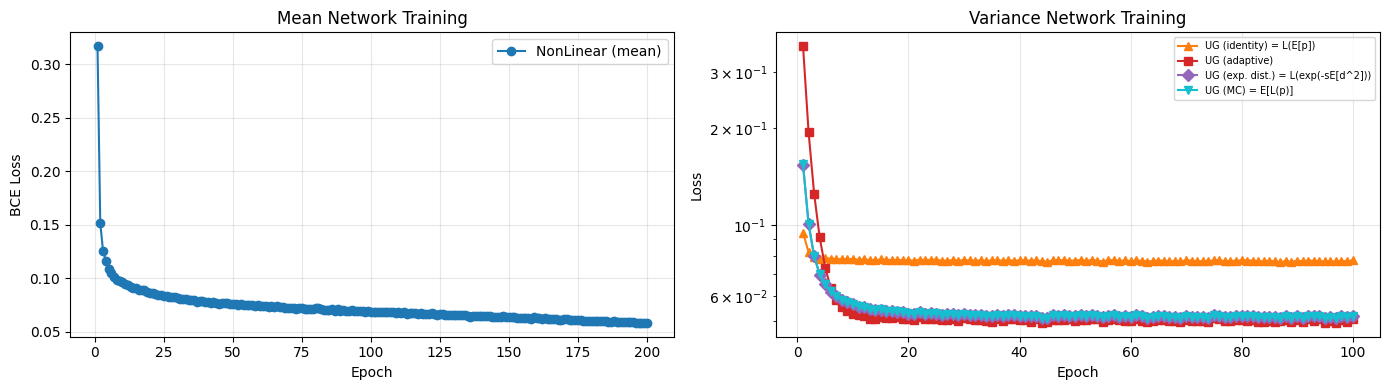

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(range(1, len(loss_nl) + 1), loss_nl, 'o-', label='NonLinear (mean)')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Mean Network Training')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(range(1, len(loss_ug_id) + 1), loss_ug_id, '^-', color='tab:orange', label='UG (identity) = L(E[p])')
ax.plot(range(1, len(loss_ug_ad) + 1), loss_ug_ad, 's-', color='tab:red', label='UG (adaptive)')
ax.plot(range(1, len(loss_ug_ed) + 1), loss_ug_ed, 'D-', color='tab:purple', label='UG (exp. dist.) = L(exp(-sE[d^2]))')
ax.plot(range(1, len(loss_ug_mc) + 1), loss_ug_mc, 'v-', color='tab:cyan', label='UG (MC) = E[L(p)]')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Variance Network Training')
ax.legend(fontsize=7)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Embed & Variance Statistics

Embed the test set with all models and compare variance distributions.
The MC model should produce **smaller variances** than the identity form
because positive pairs always penalize variance (no sign flip).

In [7]:
emb_nl = model_nl.embed(test_seqs)
emb_lla = model_lla.embed(test_seqs)
emb_ug_id = model_ug_id.embed(test_seqs)
emb_ug_ad = model_ug_ad.embed(test_seqs)
emb_ug_ed = model_ug_ed.embed(test_seqs)
emb_ug_mc = model_ug_mc.embed(test_seqs)

print(f'NonLinear:       mean {emb_nl.mean.shape}, probabilistic={emb_nl.is_probabilistic}')
print(f'LLA:             mean {emb_lla.mean.shape}, var {emb_lla.variance.shape}')
print(f'UG (identity):   mean {emb_ug_id.mean.shape}, var {emb_ug_id.variance.shape}')
print(f'UG (adaptive):   mean {emb_ug_ad.mean.shape}, var {emb_ug_ad.variance.shape}')
print(f'UG (exp. dist.): mean {emb_ug_ed.mean.shape}, var {emb_ug_ed.variance.shape}')
print(f'UG (MC):         mean {emb_ug_mc.mean.shape}, var {emb_ug_mc.variance.shape}')

print('\nVariance statistics:')
for name, emb in [('UG (identity)', emb_ug_id), ('UG (adaptive)', emb_ug_ad),
                   ('UG (exp. dist.)', emb_ug_ed), ('UG (MC)', emb_ug_mc), ('LLA', emb_lla)]:
    v = emb.variance
    print(f'  {name:18s}  mean={v.mean():.6f}, std={v.std():.6f}, min={v.min():.6f}, max={v.max():.6f}')

NonLinear:       mean (6000, 256), probabilistic=False
LLA:             mean (6000, 256), var (6000, 256)
UG (identity):   mean (6000, 256), var (6000, 256)
UG (adaptive):   mean (6000, 256), var (6000, 256)
UG (exp. dist.): mean (6000, 256), var (6000, 256)
UG (MC):         mean (6000, 256), var (6000, 256)

Variance statistics:
  UG (identity)       mean=0.001952, std=0.001176, min=0.000000, max=0.011347
  UG (adaptive)       mean=0.639932, std=0.217072, min=0.005399, max=1.996934
  UG (exp. dist.)     mean=0.000031, std=0.000015, min=0.000002, max=0.000181
  UG (MC)             mean=0.000031, std=0.000014, min=0.000002, max=0.000173
  LLA                 mean=0.001660, std=0.000526, min=0.000676, max=0.008541


## Clustering & Evaluation

All probabilistic models use their respective probabilistic similarity for clustering.

**MC model similarity:** The MC loss optimizes $\mathbb{E}_z[\mathcal{L}(\exp(-s\|z_i-z_j\|^2), y)]$.
The similarity inside the loss is $p = \exp(-s\|z_i-z_j\|^2)$, so the natural test-time
similarity is its expectation under the Gaussian:

$$\mathbb{E}[p] = \mathbb{E}\bigl[\exp(-s\|\mathbf{z}_i - \mathbf{z}_j\|^2)\bigr]
= \prod_d \frac{1}{\sqrt{1 + 2s\,v_d}}\,\exp\!\Bigl(-\frac{s\,\delta_d^2}{1 + 2s\,v_d}\Bigr)$$

where $v_d = \sigma_{i,d}^2 + \sigma_{j,d}^2$. This is exactly the **identity form**
(Lemma 3.1) with $\alpha = \frac{1}{2s}$. Since $s=1$, the MC model uses
`k_form='identity'` with $\alpha = 0.5$ for clustering.

In [8]:
METRIC = 'l2'
MIN_BIN_SIZE = 5
KMEDOID_METHOD = 'alternate'
train_labels_num = np.array([lab2id[l] for l in train_labels])

# MC model uses identity form with alpha = 1/(2*scale) = 0.5
MC_ALPHA = 1.0 / (2.0 * MC_SCALE)  # = 0.5 when scale=1.0

results = {}

# --- NonLinear (deterministic) ---
train_emb_nl = model_nl.embed(train_seqs)
pv_nl, scale_nl = compute_class_center_medium_similarity(
    train_emb_nl.point_estimate, train_labels_num, metric=METRIC)
threshold_nl = pv_nl[-3]
kmed_nl = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                            scale=scale_nl, method=KMEDOID_METHOD)
pred_nl = kmed_nl.fit_predict(emb_nl, min_similarity=threshold_nl)
r_nl = count_high_quality_clusters(test_labels, pred_nl)
assigned_nl = (pred_nl != -1).sum()
k_nl = len(set(pred_nl[pred_nl != -1].tolist())) if assigned_nl > 0 else 0
results['NonLinear'] = (r_nl, k_nl, assigned_nl, pred_nl, 'tab:blue')
print(f'NonLinear: k={k_nl}, F1>0.5={r_nl["counts"][4]}')

# --- LLA (probabilistic) ---
train_emb_lla = model_lla.embed(train_seqs)
pv_lla, scale_lla = compute_class_center_medium_similarity(
    train_emb_lla.point_estimate, train_labels_num, metric=METRIC,
    variances=train_emb_lla.variance)
threshold_lla = pv_lla[-3]
kmed_lla = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                             scale=scale_lla, method=KMEDOID_METHOD)
pred_lla = kmed_lla.fit_predict(emb_lla, min_similarity=threshold_lla)
r_lla = count_high_quality_clusters(test_labels, pred_lla)
assigned_lla = (pred_lla != -1).sum()
k_lla = len(set(pred_lla[pred_lla != -1].tolist())) if assigned_lla > 0 else 0
results['LLA'] = (r_lla, k_lla, assigned_lla, pred_lla, 'tab:green')
print(f'LLA: k={k_lla}, F1>0.5={r_lla["counts"][4]}')

# --- UG Identity (probabilistic, alpha=1.0) ---
train_emb_ug_id = model_ug_id.embed(train_seqs)
pv_ug_id, scale_ug_id = compute_class_center_medium_similarity(
    train_emb_ug_id.point_estimate, train_labels_num, metric=METRIC,
    variances=train_emb_ug_id.variance, k_form='identity', alpha=ALPHA)
threshold_ug_id = pv_ug_id[-3]
kmed_ug_id = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                               scale=scale_ug_id, method=KMEDOID_METHOD,
                               k_form='identity', alpha=ALPHA)
pred_ug_id = kmed_ug_id.fit_predict(emb_ug_id, min_similarity=threshold_ug_id)
r_ug_id = count_high_quality_clusters(test_labels, pred_ug_id)
assigned_ug_id = (pred_ug_id != -1).sum()
k_ug_id = len(set(pred_ug_id[pred_ug_id != -1].tolist())) if assigned_ug_id > 0 else 0
results['UG (identity)'] = (r_ug_id, k_ug_id, assigned_ug_id, pred_ug_id, 'tab:orange')
print(f'UG (identity): k={k_ug_id}, F1>0.5={r_ug_id["counts"][4]}')

# --- UG Adaptive (probabilistic) ---
train_emb_ug_ad = model_ug_ad.embed(train_seqs)
pv_ug_ad, scale_ug_ad = compute_class_center_medium_similarity(
    train_emb_ug_ad.point_estimate, train_labels_num, metric=METRIC,
    variances=train_emb_ug_ad.variance, k_form='adaptive')
threshold_ug_ad = pv_ug_ad[-3]
kmed_ug_ad = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                               scale=scale_ug_ad, method=KMEDOID_METHOD,
                               k_form='adaptive')
pred_ug_ad = kmed_ug_ad.fit_predict(emb_ug_ad, min_similarity=threshold_ug_ad)
r_ug_ad = count_high_quality_clusters(test_labels, pred_ug_ad)
assigned_ug_ad = (pred_ug_ad != -1).sum()
k_ug_ad = len(set(pred_ug_ad[pred_ug_ad != -1].tolist())) if assigned_ug_ad > 0 else 0
results['UG (adaptive)'] = (r_ug_ad, k_ug_ad, assigned_ug_ad, pred_ug_ad, 'tab:red')
print(f'UG (adaptive): k={k_ug_ad}, F1>0.5={r_ug_ad["counts"][4]}')

# --- UG Expected Distance (probabilistic) ---
train_emb_ug_ed = model_ug_ed.embed(train_seqs)
pv_ug_ed, scale_ug_ed = compute_class_center_medium_similarity(
    train_emb_ug_ed.point_estimate, train_labels_num, metric=METRIC,
    variances=train_emb_ug_ed.variance, k_form='expected_distance')
threshold_ug_ed = pv_ug_ed[-3]
kmed_ug_ed = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                               scale=scale_ug_ed, method=KMEDOID_METHOD,
                               k_form='expected_distance')
pred_ug_ed = kmed_ug_ed.fit_predict(emb_ug_ed, min_similarity=threshold_ug_ed)
r_ug_ed = count_high_quality_clusters(test_labels, pred_ug_ed)
assigned_ug_ed = (pred_ug_ed != -1).sum()
k_ug_ed = len(set(pred_ug_ed[pred_ug_ed != -1].tolist())) if assigned_ug_ed > 0 else 0
results['UG (exp. dist.)'] = (r_ug_ed, k_ug_ed, assigned_ug_ed, pred_ug_ed, 'tab:purple')
print(f'UG (exp. dist.): k={k_ug_ed}, F1>0.5={r_ug_ed["counts"][4]}')

# --- UG MC (identity form with alpha=1/(2s)=0.5 -- E[exp(-s*d^2)] similarity) ---
train_emb_ug_mc = model_ug_mc.embed(train_seqs)
pv_mc, scale_mc = compute_class_center_medium_similarity(
    train_emb_ug_mc.point_estimate, train_labels_num, metric=METRIC,
    variances=train_emb_ug_mc.variance, k_form='identity', alpha=MC_ALPHA)
threshold_mc = pv_mc[-3]
kmed_mc = KMedoidClusterer(metric=METRIC, min_bin_size=MIN_BIN_SIZE,
                            scale=scale_mc, method=KMEDOID_METHOD,
                            k_form='identity', alpha=MC_ALPHA)
pred_ug_mc = kmed_mc.fit_predict(emb_ug_mc, min_similarity=threshold_mc)
r_ug_mc = count_high_quality_clusters(test_labels, pred_ug_mc)
assigned_ug_mc = (pred_ug_mc != -1).sum()
k_ug_mc = len(set(pred_ug_mc[pred_ug_mc != -1].tolist())) if assigned_ug_mc > 0 else 0
results['UG (MC)'] = (r_ug_mc, k_ug_mc, assigned_ug_mc, pred_ug_mc, 'tab:cyan')
print(f'UG (MC): k={k_ug_mc}, F1>0.5={r_ug_mc["counts"][4]}')

Auto-calibrated scale: 2.997387 (median raw distance: 0.2313)
Percentile values: [0.12450093482649371, 0.2280380439922255, 0.3230909830239522, 0.41105853727277486, 0.5000850313731194, 0.5835276401654267, 0.6581730939166871, 0.73087140859097, 0.8041553183219755]
KMedoids: k_est=123, n=6000, method=alternate
NonLinear: k=121, F1>0.5=40
Auto-calibrated scale: 0.008693 (median raw distance: 79.7371)
Percentile values: [0.10202571749687195, 0.2005641609430313, 0.3002845048904419, 0.4026319980621338, 0.5000460743904114, 0.5899897217750549, 0.6735953092575073, 0.7465170621871948, 0.8236982226371765]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [00:40<00:00]


KMedoids: k_est=118, n=6000, method=alternate
LLA: k=93, F1>0.5=17
Auto-calibrated scale: 1.192968 (median raw distance: 0.5810)
Percentile values: [0.2528558671474457, 0.29359570145606995, 0.34250274300575256, 0.4220806658267975, 0.5000014305114746, 0.5700944662094116, 0.6304619908332825, 0.6834898591041565, 0.7340532541275024]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [01:45<00:00]


KMedoids: k_est=42, n=6000, method=alternate
UG (identity): k=42, F1>0.5=3
Auto-calibrated scale: 0.639070 (median raw distance: 1.0846)
Percentile values: [0.1219196617603302, 0.22511707246303558, 0.3233273923397064, 0.40972086787223816, 0.5000096559524536, 0.5794991254806519, 0.6569945216178894, 0.7303972840309143, 0.8053097128868103]


...

KMedoids: k_est=127, n=6000, method=alternate
UG (adaptive): k=125, F1>0.5=32
Auto-calibrated scale: 2.803843 (median raw distance: 0.2472)
Percentile values: [0.13492640852928162, 0.23770548403263092, 0.3302474021911621, 0.4155106246471405, 0.5000245571136475, 0.5803443193435669, 0.6511720418930054, 0.7187567949295044, 0.7872401475906372]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [00:26<00:00]


KMedoids: k_est=119, n=6000, method=alternate
UG (exp. dist.): k=118, F1>0.5=32
Auto-calibrated scale: 2.806521 (median raw distance: 0.2470)
Percentile values: [0.13492657244205475, 0.2376750409603119, 0.33055493235588074, 0.4152586758136749, 0.5000332593917847, 0.5805479884147644, 0.651001513004303, 0.718802273273468, 0.7872313261032104]


 Computing probabilistic similarity │██████████████████████████████│ 12/12 [01:24<00:00]


KMedoids: k_est=119, n=6000, method=alternate
UG (MC): k=118, F1>0.5=34


## Results Comparison

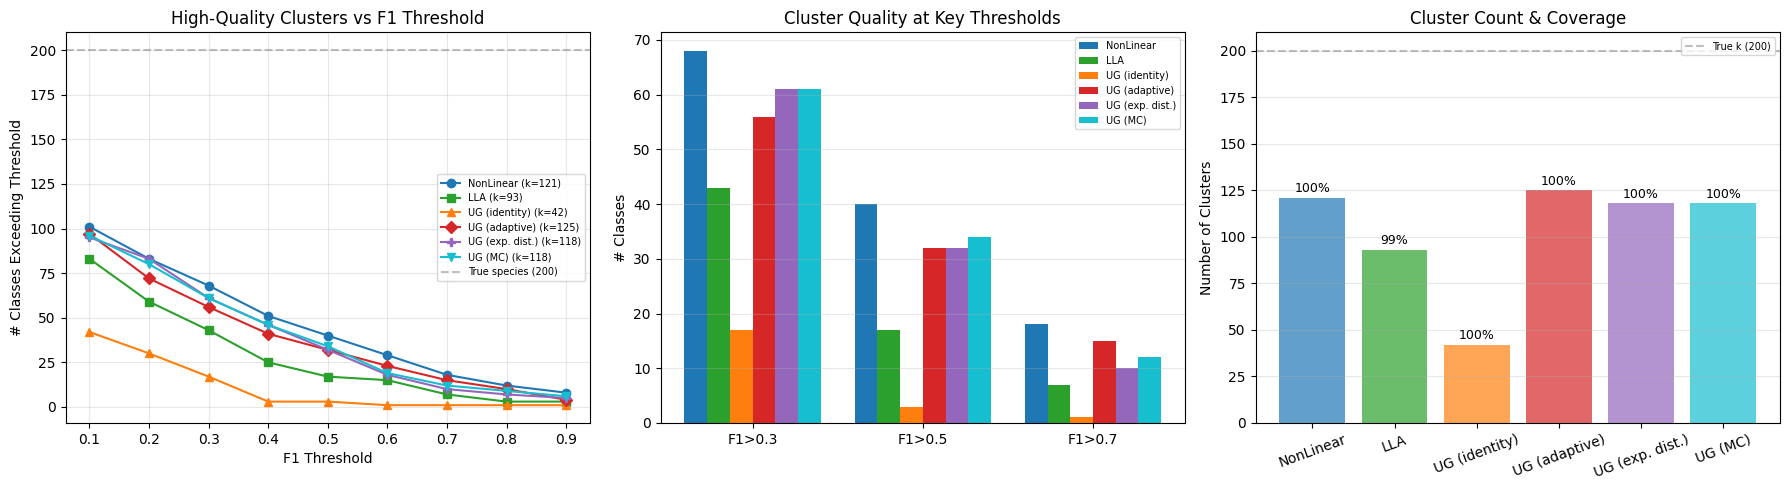

In [9]:
thresholds = r_nl['thresholds']
all_results = [
    ('NonLinear', *results['NonLinear']),
    ('LLA', *results['LLA']),
    ('UG (identity)', *results['UG (identity)']),
    ('UG (adaptive)', *results['UG (adaptive)']),
    ('UG (exp. dist.)', *results['UG (exp. dist.)']),
    ('UG (MC)', *results['UG (MC)']),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# F1 threshold curve
ax = axes[0]
markers = ['o', 's', '^', 'D', 'P', 'v']
for (name, r, k, _, _, color), marker in zip(all_results, markers):
    ax.plot(thresholds, r['counts'], f'{marker}-', label=f'{name} (k={k})', color=color)
ax.axhline(n_species, ls='--', color='gray', alpha=0.5, label=f'True species ({n_species})')
ax.set_xlabel('F1 Threshold')
ax.set_ylabel('# Classes Exceeding Threshold')
ax.set_title('High-Quality Clusters vs F1 Threshold')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Grouped bar chart
ax = axes[1]
key_thresholds = [0.3, 0.5, 0.7]
key_idx = [thresholds.index(t) for t in key_thresholds]
n_models = len(all_results)
x = np.arange(len(key_thresholds))
w = 0.8 / n_models
for i, (name, r, _, _, _, color) in enumerate(all_results):
    offset = (i - n_models / 2 + 0.5) * w
    ax.bar(x + offset, [r['counts'][j] for j in key_idx], w, label=name, color=color)
ax.set_xticks(x)
ax.set_xticklabels([f'F1>{t}' for t in key_thresholds])
ax.set_ylabel('# Classes')
ax.set_title('Cluster Quality at Key Thresholds')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3, axis='y')

# k estimation and coverage
ax = axes[2]
model_names = [r[0] for r in all_results]
k_vals = [r[2] for r in all_results]
coverages = [r[3] / len(r[4]) for r in all_results]
colors = [r[5] for r in all_results]
ax.bar(model_names, k_vals, color=colors, alpha=0.7)
ax.axhline(n_species, ls='--', color='gray', alpha=0.5, label=f'True k ({n_species})')
ax.set_ylabel('Number of Clusters')
ax.set_title('Cluster Count & Coverage')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=20)
for i, (name, k, cov) in enumerate(zip(model_names, k_vals, coverages)):
    ax.text(i, k + 3, f'{cov:.0%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Cluster Visualization (t-SNE)

2D t-SNE projection of the test embeddings. All models share the same mean network,
so a single t-SNE is computed once and reused. Points are colored by true species label
(top-left) or predicted cluster (others). Gray = unassigned ($-1$).

Computing t-SNE projection...
t-SNE done: (6000, 2)


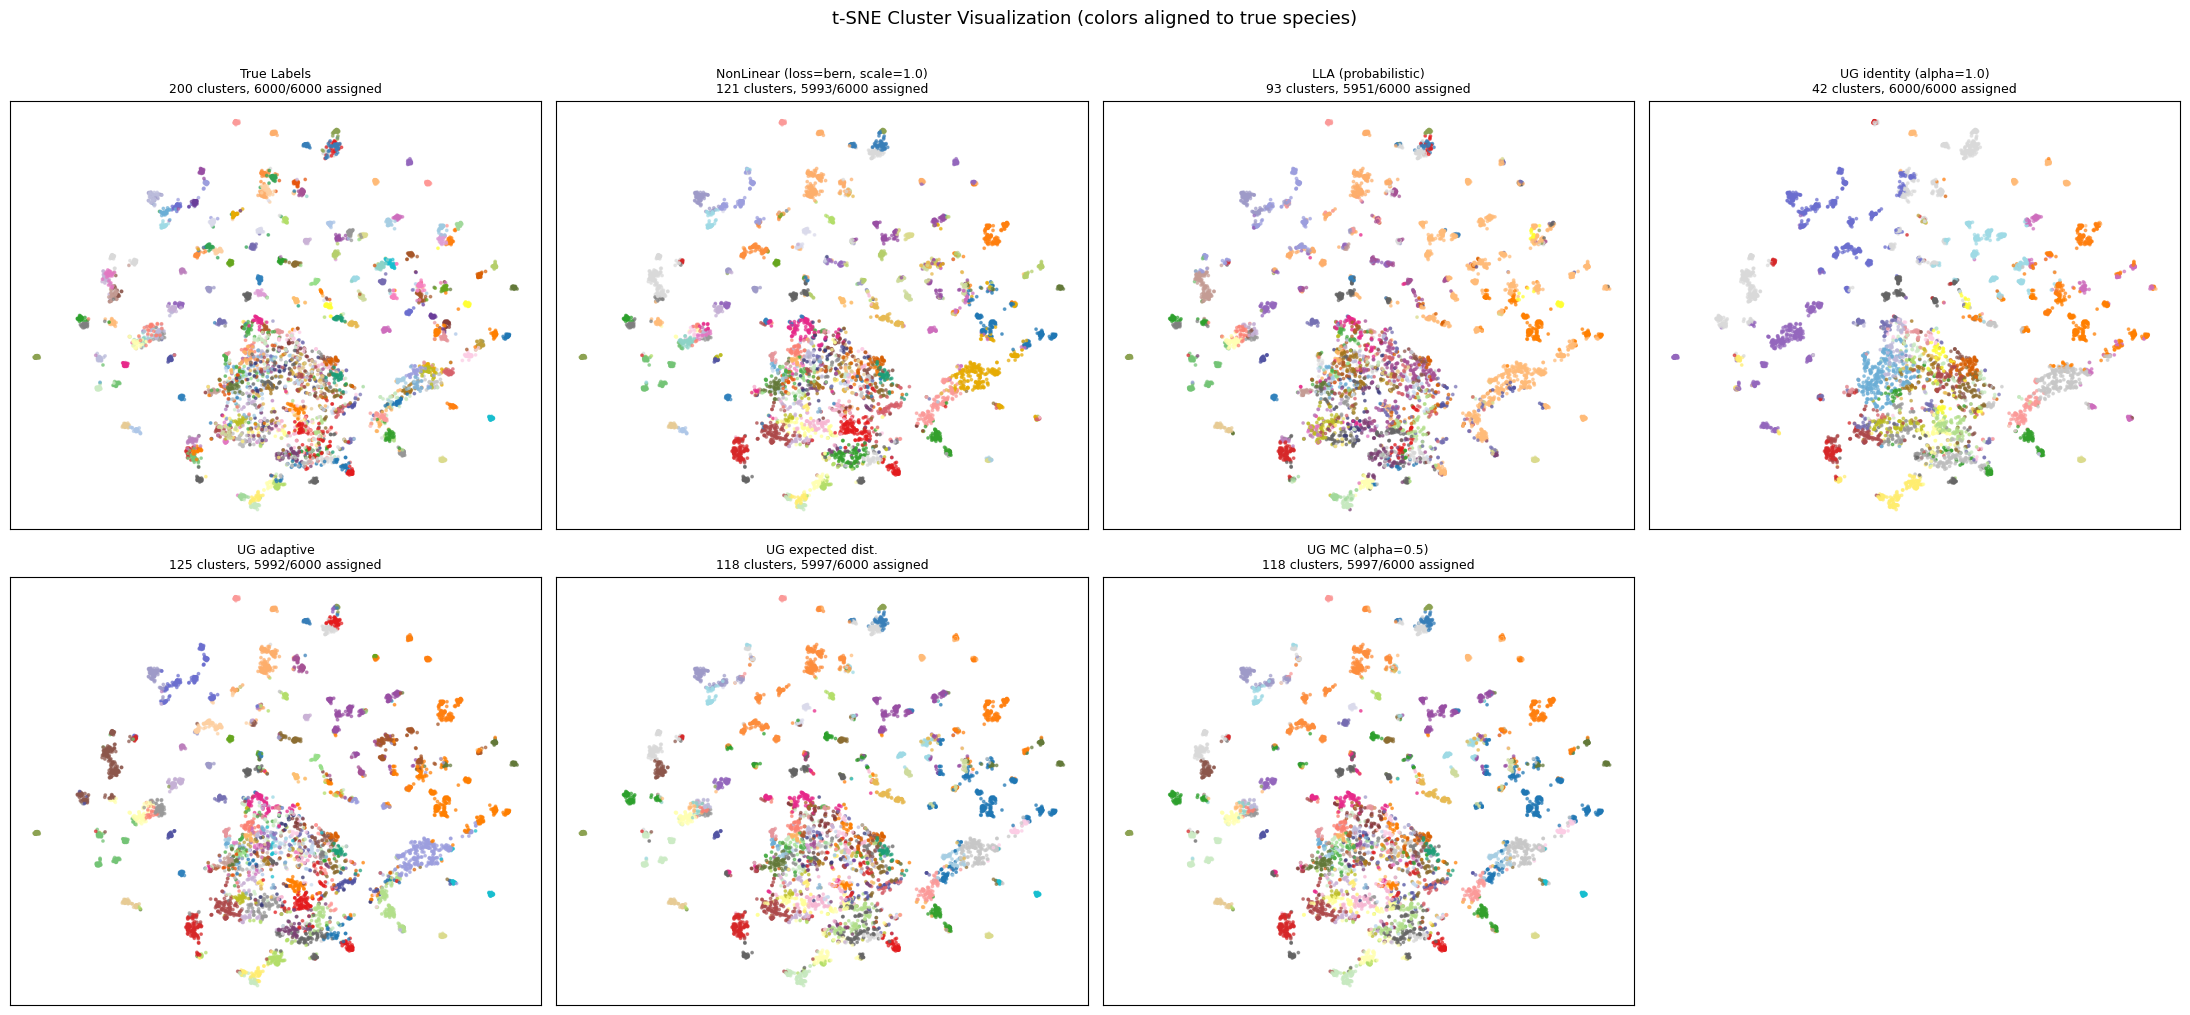

In [10]:
from sklearn.manifold import TSNE

# Compute t-SNE once (all models share the same mean embeddings)
print("Computing t-SNE projection...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
coords = tsne.fit_transform(emb_nl.mean)
print(f"t-SNE done: {coords.shape}")

# Color map: assign each true species a unique color
point_size = 3
point_alpha = 0.6

true_unique = np.unique(test_labels)
n_true = len(true_unique)
base_colors = np.vstack([
    plt.cm.tab20(np.linspace(0, 1, 20)),
    plt.cm.tab20b(np.linspace(0, 1, 20)),
    plt.cm.tab20c(np.linspace(0, 1, 20)),
    plt.cm.Set1(np.linspace(0, 1, 9)),
    plt.cm.Set3(np.linspace(0, 1, 12)),
    plt.cm.Dark2(np.linspace(0, 1, 8)),
    plt.cm.Paired(np.linspace(0, 1, 12)),
])
species_colors = np.tile(base_colors, (max(1, n_true // len(base_colors) + 1), 1))[:n_true]
true_label_to_color = {lab: species_colors[i] for i, lab in enumerate(true_unique)}

def plot_clusters_aligned(ax, coords, labels, title, alignment=None):
    mask_assigned = labels != -1
    mask_unassigned = ~mask_assigned
    if mask_unassigned.any():
        ax.scatter(coords[mask_unassigned, 0], coords[mask_unassigned, 1],
                   c="lightgray", s=point_size, alpha=0.3, rasterized=True)
    if mask_assigned.any():
        if alignment is not None:
            mapped = np.array([alignment.get(l, -1) for l in labels[mask_assigned]])
            c = np.array([true_label_to_color.get(m, [0.7, 0.7, 0.7, 1.0]) for m in mapped])
        else:
            c = np.array([true_label_to_color[l] for l in labels[mask_assigned]])
        ax.scatter(coords[mask_assigned, 0], coords[mask_assigned, 1],
                   c=c, s=point_size, alpha=point_alpha, rasterized=True)
    n_clusters = len(np.unique(labels[mask_assigned])) if mask_assigned.any() else 0
    n_assigned = int(mask_assigned.sum())
    ax.set_title(f"{title}\n{n_clusters} clusters, {n_assigned}/{len(labels)} assigned", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

def get_alignment(true_labels, pred_labels):
    mask = pred_labels != -1
    if mask.sum() < 2:
        return {}
    return align_labels_via_hungarian_algorithm(true_labels[mask], pred_labels[mask])

align_nl_tsne = get_alignment(test_labels, pred_nl)
align_lla_tsne = get_alignment(test_labels, pred_lla)
align_ug_id_tsne = get_alignment(test_labels, pred_ug_id)
align_ug_ad_tsne = get_alignment(test_labels, pred_ug_ad)
align_ug_ed_tsne = get_alignment(test_labels, pred_ug_ed)
align_ug_mc_tsne = get_alignment(test_labels, pred_ug_mc)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

plot_clusters_aligned(axes[0, 0], coords, test_labels, "True Labels")
plot_clusters_aligned(axes[0, 1], coords, pred_nl,
                      f"NonLinear (loss={LOSS_NAME}, scale={LOSS_SCALE})",
                      alignment=align_nl_tsne)
plot_clusters_aligned(axes[0, 2], coords, pred_lla, "LLA (probabilistic)",
                      alignment=align_lla_tsne)
plot_clusters_aligned(axes[0, 3], coords, pred_ug_id, f"UG identity (alpha={ALPHA})",
                      alignment=align_ug_id_tsne)
plot_clusters_aligned(axes[1, 0], coords, pred_ug_ad, f"UG adaptive",
                      alignment=align_ug_ad_tsne)
plot_clusters_aligned(axes[1, 1], coords, pred_ug_ed, f"UG expected dist.",
                      alignment=align_ug_ed_tsne)
plot_clusters_aligned(axes[1, 2], coords, pred_ug_mc, f"UG MC (alpha={MC_ALPHA})",
                      alignment=align_ug_mc_tsne)
axes[1, 3].axis('off')

plt.suptitle("t-SNE Cluster Visualization (colors aligned to true species)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Uncertainty Heatmap (t-SNE)

Same t-SNE coordinates as above, but colored by $\log_{10}(\text{mean variance})$ per sample
using a red (high) to green (low) colormap. This shows the spatial distribution of uncertainty.

**What to look for:** If uncertainty is useful, high-variance points should concentrate at
cluster boundaries or in ambiguous regions (between clusters). If instead high-variance
points are scattered uniformly, the uncertainty is not spatially informative.

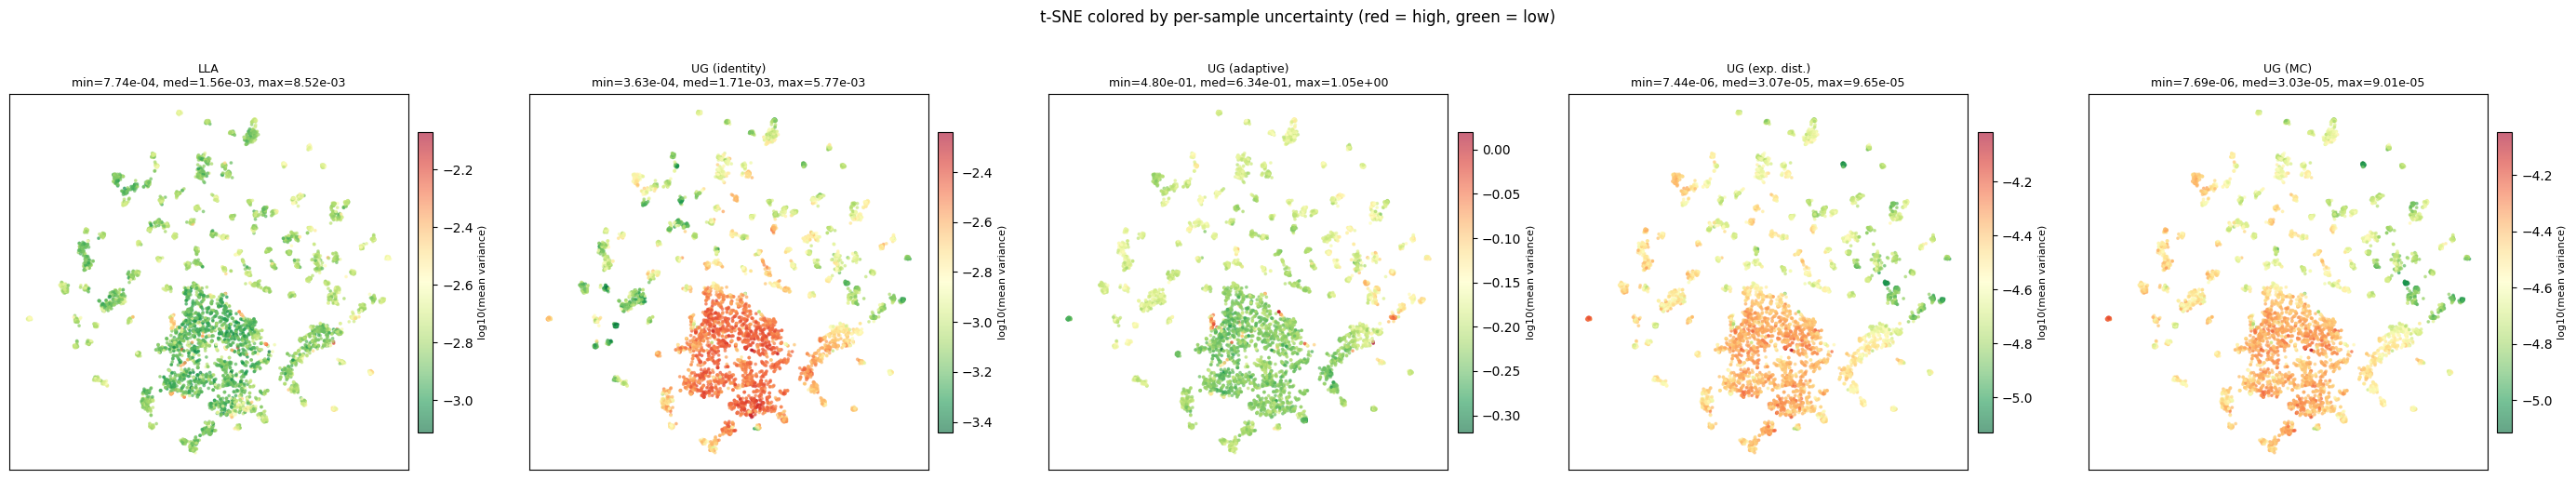

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

unc_models = [
    ("LLA",             emb_lla.variance.mean(axis=1)),
    ("UG (identity)",   emb_ug_id.variance.mean(axis=1)),
    ("UG (adaptive)",   emb_ug_ad.variance.mean(axis=1)),
    ("UG (exp. dist.)", emb_ug_ed.variance.mean(axis=1)),
    ("UG (MC)",         emb_ug_mc.variance.mean(axis=1)),
]

for ax, (name, unc) in zip(axes, unc_models):
    log_unc = np.log10(unc + 1e-12)
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=log_unc, s=3, alpha=0.6,
                    cmap="RdYlGn_r", rasterized=True)
    cb = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label("log10(mean variance)", fontsize=8)
    ax.set_title(f"{name}\nmin={unc.min():.2e}, med={np.median(unc):.2e}, max={unc.max():.2e}",
                 fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("t-SNE colored by per-sample uncertainty (red = high, green = low)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Selective Prediction

The key question: does the MC-trained variance produce better uncertainty
estimates for selective prediction? All models use NonLinear's clustering
(the best deterministic baseline) and only vary the rejection signal.
This isolates "is the variance a good confidence measure?" from
"is the probabilistic similarity good for clustering?"

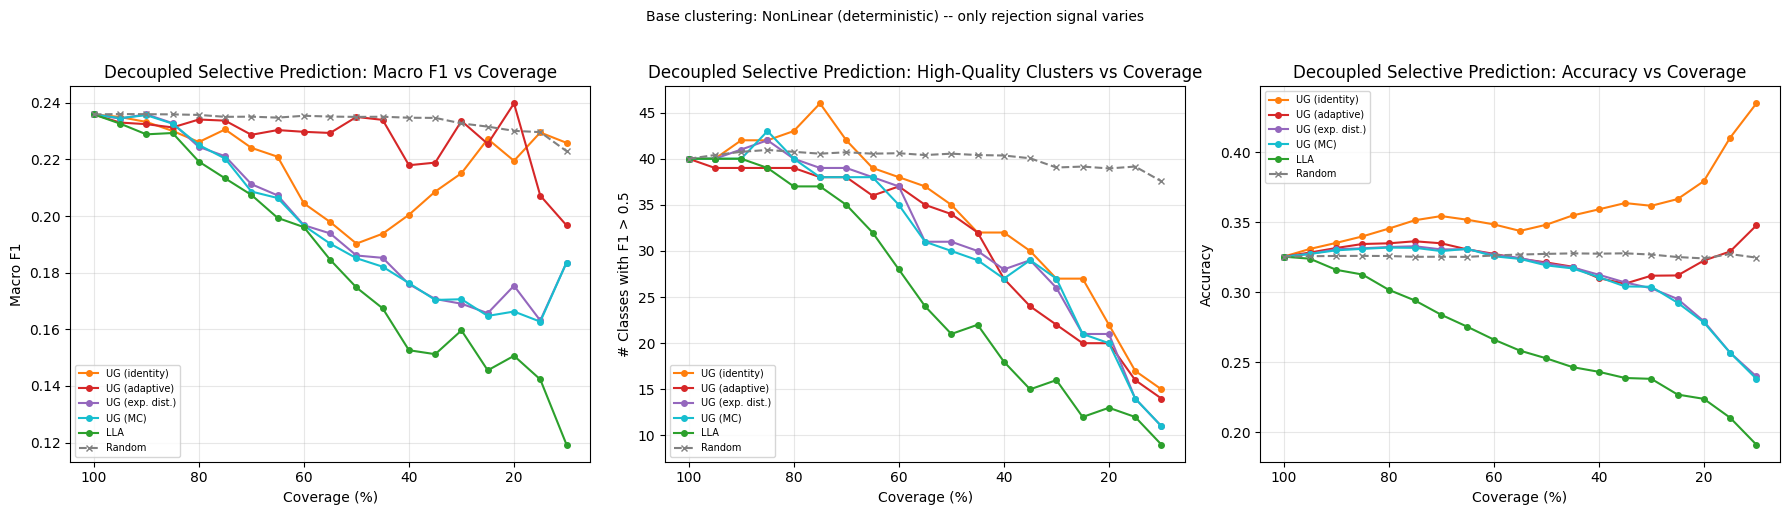


Base clustering: NonLinear (F1>0.5=40, k=121)
Uncertainty signal   F1@100%  F1@80%  F1@60%  F1@40%  |  Acc@100%  Acc@80%  Acc@60%  Acc@40%
------------------------------------------------------------------------------------------
UG (identity)         0.236   0.226   0.204   0.200  |   0.326   0.346   0.349   0.359
UG (adaptive)         0.236   0.234   0.230   0.218  |   0.326   0.335   0.328   0.310
UG (exp. dist.)       0.236   0.224   0.197   0.176  |   0.326   0.332   0.327   0.313
UG (MC)               0.236   0.225   0.197   0.176  |   0.326   0.332   0.326   0.311
LLA                   0.236   0.219   0.196   0.153  |   0.326   0.302   0.266   0.243


In [12]:
def selective_curves_fixed(true_labels, pred_labels, uncertainties, coverages, alignment):
    n = len(true_labels)
    order = np.argsort(uncertainties)
    f1_scores, f1_gt05_counts, acc_scores = [], [], []
    for cov in coverages:
        k = max(1, int(n * cov))
        keep = order[:k]
        tl, pl = true_labels[keep], pred_labels[keep]
        mask = pl != -1
        if mask.sum() < 2:
            f1_scores.append(0.0); f1_gt05_counts.append(0); acc_scores.append(0.0)
            continue
        tl_m, pl_m = tl[mask], pl[mask]
        aligned = np.array([alignment.get(p, -1) for p in pl_m])
        per_f1 = sklearn.metrics.f1_score(tl_m, aligned, average=None, zero_division=0)
        f1_scores.append(np.mean(per_f1))
        f1_gt05_counts.append(int((per_f1 > 0.5).sum()))
        acc_scores.append(np.mean(aligned == tl_m))
    return np.array(f1_scores), np.array(f1_gt05_counts), np.array(acc_scores)

# Fixed alignment from NonLinear at 100% coverage
mask_base = pred_nl != -1
base_alignment = align_labels_via_hungarian_algorithm(test_labels[mask_base], pred_nl[mask_base])

coverages_d = np.linspace(1.0, 0.1, 19)

unc_ug_id = emb_ug_id.variance.mean(axis=1)
unc_ug_ad = emb_ug_ad.variance.mean(axis=1)
unc_ug_ed = emb_ug_ed.variance.mean(axis=1)
unc_ug_mc = emb_ug_mc.variance.mean(axis=1)
unc_lla = emb_lla.variance.mean(axis=1)

models_sel = [
    ('UG (identity)', unc_ug_id, 'tab:orange'),
    ('UG (adaptive)', unc_ug_ad, 'tab:red'),
    ('UG (exp. dist.)', unc_ug_ed, 'tab:purple'),
    ('UG (MC)', unc_ug_mc, 'tab:cyan'),
    ('LLA', unc_lla, 'tab:green'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, unc, color in models_sel:
    f1_c, gt05_c, acc_c = selective_curves_fixed(
        test_labels, pred_nl, unc, coverages_d, base_alignment)
    axes[0].plot(coverages_d * 100, f1_c, 'o-', label=name, color=color, markersize=4)
    axes[1].plot(coverages_d * 100, gt05_c, 'o-', label=name, color=color, markersize=4)
    axes[2].plot(coverages_d * 100, acc_c, 'o-', label=name, color=color, markersize=4)

# Random baseline
rng_d = np.random.RandomState(SEED)
rand_f1, rand_gt05, rand_acc = [], [], []
for _ in range(20):
    rand_unc = rng_d.rand(len(test_labels))
    f1_r, gt05_r, acc_r = selective_curves_fixed(
        test_labels, pred_nl, rand_unc, coverages_d, base_alignment)
    rand_f1.append(f1_r); rand_gt05.append(gt05_r); rand_acc.append(acc_r)

axes[0].plot(coverages_d * 100, np.mean(rand_f1, axis=0), 'x--', color='gray', label='Random', markersize=4)
axes[1].plot(coverages_d * 100, np.mean(rand_gt05, axis=0), 'x--', color='gray', label='Random', markersize=4)
axes[2].plot(coverages_d * 100, np.mean(rand_acc, axis=0), 'x--', color='gray', label='Random', markersize=4)

for ax, ylabel, title in zip(axes,
        ['Macro F1', '# Classes with F1 > 0.5', 'Accuracy'],
        ['Macro F1 vs Coverage', 'High-Quality Clusters vs Coverage', 'Accuracy vs Coverage']):
    ax.set_xlabel('Coverage (%)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Decoupled Selective Prediction: {title}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

plt.suptitle('Base clustering: NonLinear (deterministic) -- only rejection signal varies',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
key_covs = [100, 80, 60, 40]
print(f'\nBase clustering: NonLinear (F1>0.5={r_nl["counts"][4]}, k={k_nl})')
print(f'{"Uncertainty signal":<20s} ' + '  '.join(f'F1@{c}%' for c in key_covs)
      + '  |  ' + '  '.join(f'Acc@{c}%' for c in key_covs))
print('-' * 90)
for name, unc, _ in models_sel:
    f1_c, _, acc_c = selective_curves_fixed(
        test_labels, pred_nl, unc, coverages_d, base_alignment)
    idx = {round(c * 100): i for i, c in enumerate(coverages_d)}
    f1_v = '  '.join(f'{f1_c[idx[c]]:6.3f}' for c in key_covs)
    acc_v = '  '.join(f'{acc_c[idx[c]]:6.3f}' for c in key_covs)
    print(f'{name:<20s} {f1_v}  |  {acc_v}')

## Analysis

### Finding 1: $\mathbb{E}[\mathcal{L}(p)] \approx \mathcal{L}(\exp(-s\,\mathbb{E}[d^2]))$ in practice

The MC and expected distance models produce **nearly identical** results across all metrics:

| | MC | Expected Distance |
|---|---|---|
| Variance mean | ~3.1e-5 | ~3.1e-5 |
| Loss trajectory | 0.154 → 0.052 | 0.154 → 0.052 |
| Selective F1@40% | ~identical | ~identical |

**Why?** For **positive pairs**, the two losses are *mathematically identical*:

$$\mathbb{E}[-\log p] = s\,\mathbb{E}[\|z_i - z_j\|^2] = s\bigl(\|\delta\|^2 + \textstyle\sum_d v_d\bigr)$$

which is exactly what the expected distance form computes. Both give gradient
$\partial/\partial v_d = s > 0$, always penalizing variance.

For **negative pairs**, the difference is governed by Jensen's inequality:

$$-\log\bigl(1 - e^{-s\,\mathbb{E}[d^2]}\bigr) \;\leq\; \mathbb{E}\bigl[-\log(1 - e^{-s\,d^2})\bigr]$$

But with 20 negative samples per positive, most negatives are **well-separated**
($\|\delta\| \gg 0 \Rightarrow p \approx 0 \Rightarrow$ loss $\approx 0$). The Jensen gap
is negligible because the function $-\log(1-e^{-x})$ is nearly linear for large $x$.
Only hard negatives ($\|\delta\| \approx 0$) would show a difference, but these are rare.

**Implication:** MC sampling adds $K\times$ computational cost (8 forward passes per pair)
for no measurable benefit over the closed-form expected distance. The two objectives
are practically equivalent when negatives are well-separated.

### Finding 2: Identity form produces the best uncertainty for selective prediction

Among all variance forms, the identity form ($\alpha=1.0$) achieves the highest
accuracy at low coverage (selective prediction), though the adaptive form achieves the highest macro F1 at low coverage. This is because it produces
**more dynamic range** in the variances (mean=0.002 vs 0.00003 for MC/exp. dist.):

- The identity form gradient allows variance to *increase* in high-residual dimensions
  ($\delta_d^2 > v_d + \alpha$), capturing per-dimension epistemic uncertainty.
- MC and expected distance always push variance *down* for positive pairs,
  leading to near-zero variances with little discriminative power.

The larger variance range in the identity form provides better separation between
confident and uncertain samples — exactly what selective prediction needs.

### Finding 3: Clustering with the identity form is sensitive to $\alpha$

The identity form similarity includes a log-normalizer term that creates a
positive floor on the distance even when $\delta = 0$:

$$d_{\text{identity}} = \sum_d \Bigl[\frac{1}{2}\log\frac{v_d + \alpha}{\alpha} + \frac{\delta_d^2}{2(v_d + \alpha)}\Bigr]$$

This compresses the similarity distribution compared to deterministic L2.
The auto-calibrated threshold adapts, but the narrower spread means the
clustering is more sensitive to the exact threshold percentile chosen.

## Summary

| Model | Loss objective | Clustering similarity | $\alpha$ | Variance role |
|-------|---------------|----------------------|:---:|---------------|
| NonLinear | $\mathcal{L}(p_{\text{det}})$ | Deterministic L2 | -- | None |
| LLA | Post-hoc Laplace | Probabilistic (adaptive) | per-dim | Similarity + confidence |
| UG (identity) | $\mathcal{L}(\mathbb{E}[p])$ | Identity ($K=\alpha I$) | 1.0 | Similarity + confidence |
| UG (adaptive) | $\mathcal{L}(\mathbb{E}[p])$ | Adaptive ($K=\text{diag}$) | per-dim | Similarity + confidence |
| UG (exp. dist.) | $\mathcal{L}(\exp(-s\mathbb{E}[d^2]))$ | Expected distance | -- | Similarity + confidence |
| **UG (MC)** | $\mathbb{E}[\mathcal{L}(p)]$ | **Identity** ($K=\frac{1}{2s}I$) | **0.5** | **Similarity + confidence** |

**Key insight:** The MC model's natural test-time similarity is $\mathbb{E}[\exp(-s\|z_i-z_j\|^2)]$,
which equals the identity form with $\alpha = 1/(2s)$. This is derived from the same
closed-form expectation used for the loss -- the MC sampling is only needed for
the *loss function* (because BCE is nonlinear), not for the *similarity* itself.

Note that the MC model's $\alpha=0.5$ is smaller than the identity form's $\alpha=1.0$.
Smaller $\alpha$ means variance has a **stronger** effect on the similarity:
the denominator $v_d + \alpha$ is smaller, so the same variance produces more attenuation.